# Logical error rate
Read a run directory and plot count-weighted logical error rates with 95% Wilson confidence bands. The default figure width is 3.45 inches for one column of a two-column paper.

In [1]:
from pathlib import Path
from knill_bench.analysis.plotting import load_logical_error_rates, plot_logical_error_rates, save_figure

run = Path("../results/20260926T072423.208286Z_d9dd0e5f07")
rows = load_logical_error_rates(run)
len(rows)

64

For d=5 and 15 cycles, `se_memory` has two decoders. Select one of them before grouping by protocol so every protocol has one curve.

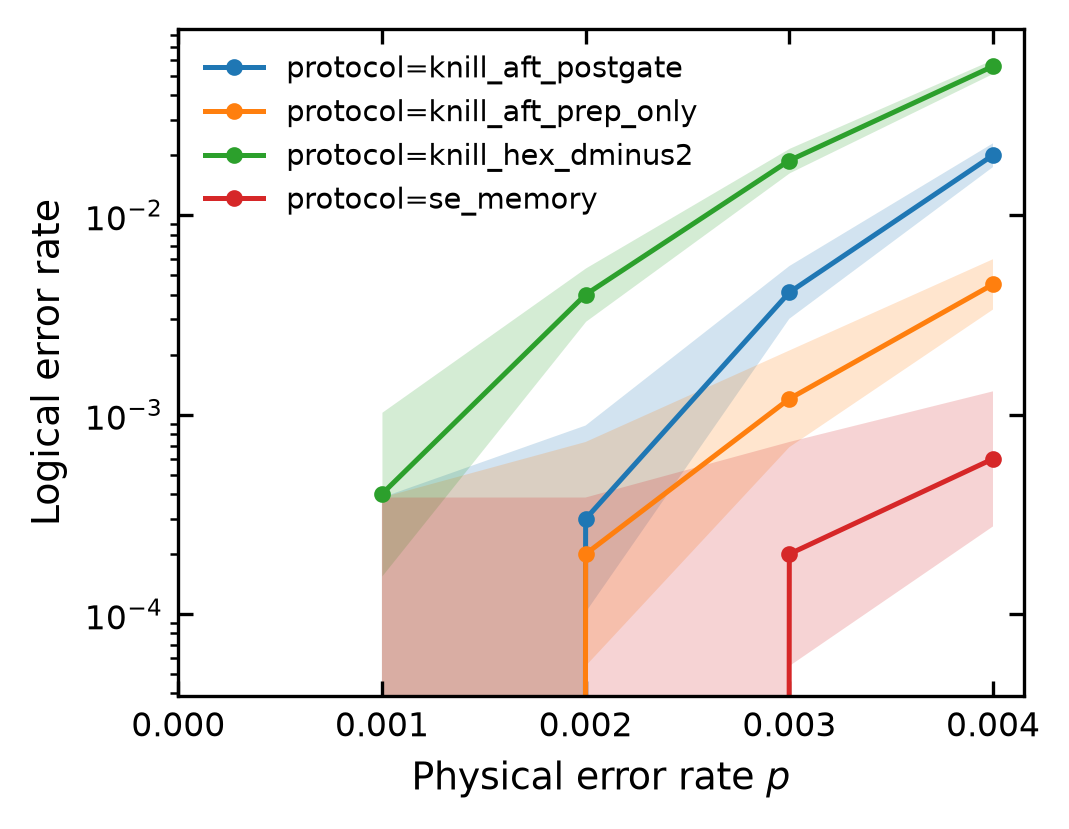

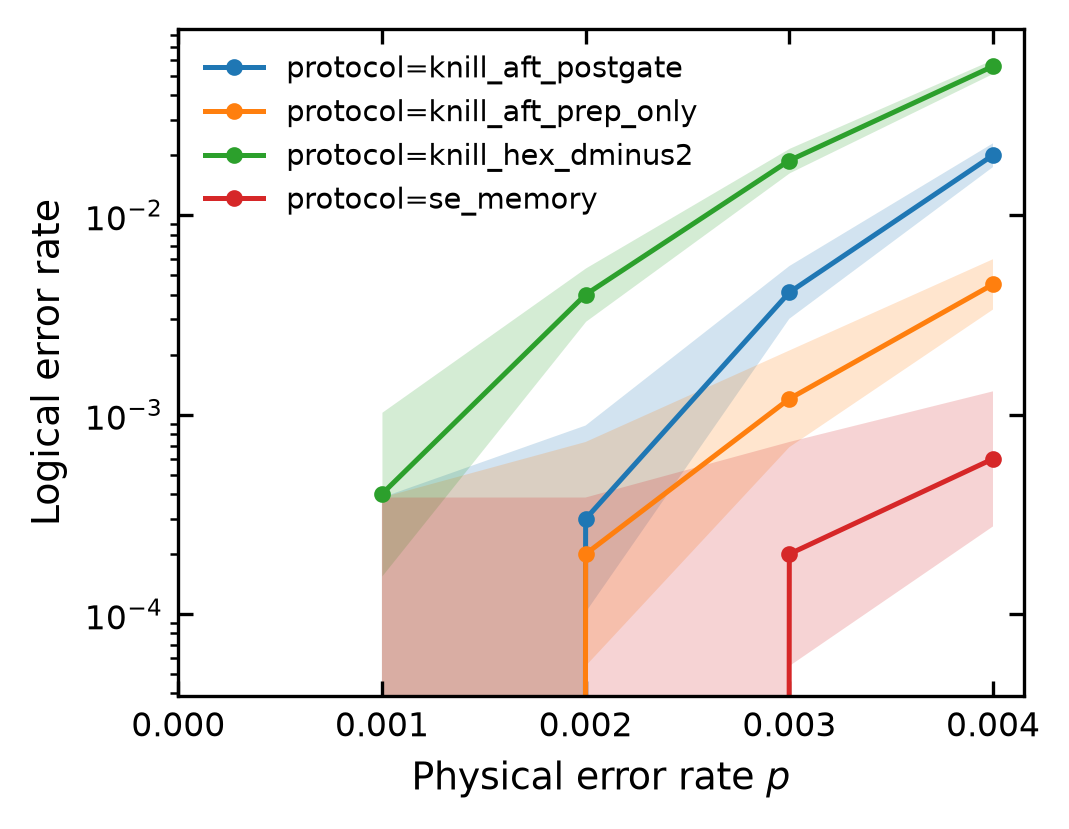

In [5]:
selected_rows = [
    r for r in rows
    if r["protocol"] != "se_memory" or r["requested_decoder"] == "mwpm"
]

fig, ax = plot_logical_error_rates(
    selected_rows,
    filters={"basis": "z", "distance": 9, "cycles": 9},
    group_by="protocol",
)
save_figure(fig, run / "plots" / "logical_error_rate_d5_cycles15.pdf")
save_figure(fig, run / "plots" / "logical_error_rate_d5_cycles15.png")
fig